# Testing other root file

The goal of this notebook is to compare the results we get from each of the other notebooks with another file. This helps us to see if the patterns repeat or if there are any inconsistencies

### Importing packages

In [2]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

### Names for each pair

In [3]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

### Open file and branches

In [9]:
# Open file
file = uproot.open("sample_root_files/ttH_output_919.root")

In [10]:
# Open Events tree
events_tree = file['Events']

In [11]:
# Making arrays of Jet pt and EFT Coefficients
jet_pt = events_tree['Jet_pt'].array()
eft_coeff = events_tree['EFTfitCoefficients'].array()

### Comparing results from sum of Jet $p_t$
For the details in the code, look at the high vs low jet $p_t$ notebook

In [12]:
# Adding the jet pt's in each event, and then making that list a numpy array (useful for the cell below)
sum_of_jet_pt_in_each_event = []

for i in range(len(jet_pt)):
    sum_of_jet_pt_in_each_event.append(sum(jet_pt[i]))

sum_of_jet_pt_in_each_event = np.array(sum_of_jet_pt_in_each_event)

In [13]:
jet_pt_above_500 = sum_of_jet_pt_in_each_event > 500
eft_coeff_above_500 = []
eft_coeff_below_500 = []

for i,n in enumerate(jet_pt_above_500):                                       
    if n == False:
        eft_coeff_below_500.append(np.argmax(np.abs(eft_coeff[i])))           # np.argmax finds the index of the largest entry.
    else:
        eft_coeff_above_500.append(np.argmax(np.abs(eft_coeff[i])))

In [14]:
jet_pt_above_500 = sum_of_jet_pt_in_each_event > 500
eft_coeff_above_500_filtering_out_SM = []
eft_coeff_below_500_filtering_out_SM = []

for i,n in enumerate(jet_pt_above_500):                                       
    if n == False:
        eft_coeff_below_500_filtering_out_SM.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)
        # +1 since the new list gets shifted by ignoring the first coefficient
    else:
        eft_coeff_above_500_filtering_out_SM.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)

In [15]:
# Making it a percentage. The difference in the amount of events is drastic.
def weights(data):
    return [1 / len(data)] * len(data)

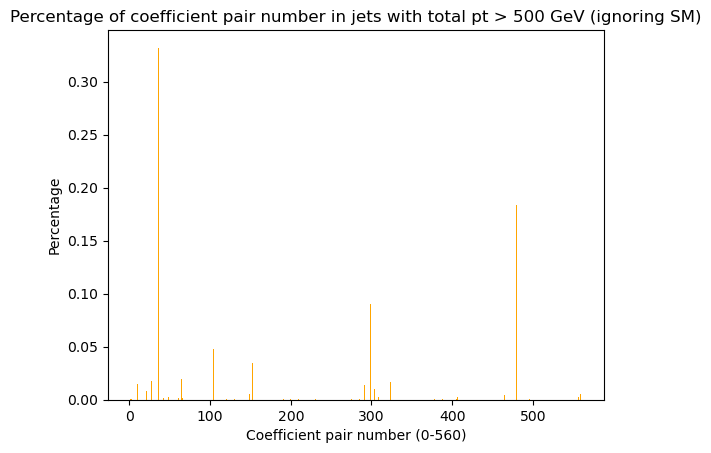

In [16]:
plt.hist(eft_coeff_above_500_filtering_out_SM, bins = 500, weights = weights(eft_coeff_above_500_filtering_out_SM), color = 'orange')
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with total pt > 500 GeV (ignoring SM)')

plt.show()

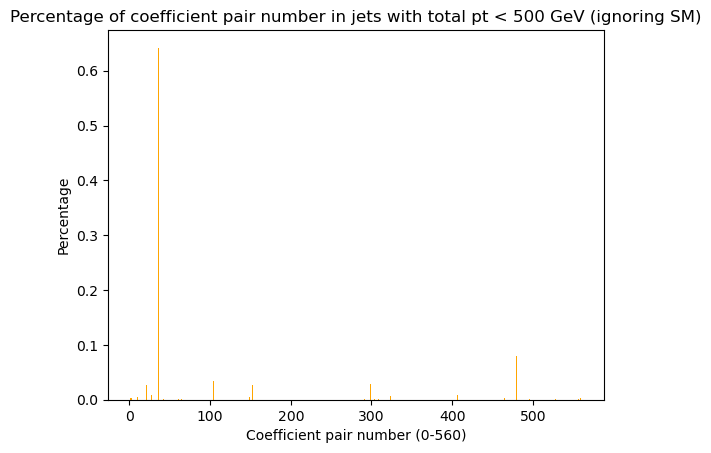

In [17]:
plt.hist(eft_coeff_below_500_filtering_out_SM, bins = 500, weights = weights(eft_coeff_below_500_filtering_out_SM), color='orange')
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with total pt < 500 GeV (ignoring SM)')

plt.show()

In [18]:
def interesting_coeff(data,high_or_low):
    for i in range(561):
        coeff_percentage = data.count(i) / len(data)
        if coeff_percentage > 0.05:
            a = print(f'The pair {name_combinations[i]} has index {i} and has a percentage {round(coeff_percentage*100)}% in {high_or_low} pt')
    return a

In [21]:
# High pt, ignoring SM
interesting_coeff(eft_coeff_above_500_filtering_out_SM,'high')

The pair ['ctG', 'SM'] has index 36 and has a percentage 33% in high pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 17% in high pt
The pair ['ctq1', 'ctq1'] has index 299 and has a percentage 9% in high pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 18% in high pt


In [22]:
# Low pt, ignoring SM
interesting_coeff(eft_coeff_below_500_filtering_out_SM,'low')

The pair ['ctG', 'SM'] has index 36 and has a percentage 64% in low pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 10% in low pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 8% in low pt
